# 05 - Embedding exploration

Two things in one notebook:

1. **Data setup** -- how to download the published full-dataset release from
   Zenodo (a finished alternative to rebuilding from raw RDF -- see the root
   `README.md` "Building the PyG" for that longer path).
2. **Embedding exploration** -- PCA / t-SNE / UMAP on the Metabolite / Protein
   / GeneProduct node embeddings from `notebooks/03_embeddings_fulldata.ipynb`,
   coloured by organism, plus a link-prediction-split diagnostic (does the
   taxa-held-out split carve out a visually distinct region of embedding
   space, or are held-out organisms intermixed with train?), plus the same
   PCA / t-SNE / UMAP treatment for the Conversion (reaction) embeddings from
   `scripts/compute_conversion_embeddings.py`, coloured by EC class instead
   of organism (Part 4).

## Part 1 -- Data setup: download the published full-dataset release

The full dataset built in `notebooks/03_embeddings_fulldata.ipynb` /
`02_build_splits.ipynb` is published on Zenodo as its own deposition,
separate from both the source PlantMetWiki RDF DOI and the Learnathon-subset
DOI (see `fulldata/zenodo_metadata.json` / `fulldata/LICENSE.md`).

**Concept DOI (cite this — always resolves to the latest version):**
[10.5281/zenodo.20847651](https://doi.org/10.5281/zenodo.20847651)

Querying the Zenodo API with the *concept* record id (rather than a specific
version's id) returns whatever the latest version actually is — the same
pattern already used for the source RDF data in the root `README.md`
("Updating to a new Zenodo data release").

In [1]:
import json
import zipfile
from pathlib import Path

import requests

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

FULL_DIR = ROOT / "data" / "processed"
CONCEPT_RECORD_ID = "20847651"  # https://doi.org/10.5281/zenodo.20847651

headers = {"User-Agent": "pathway-reaction-kg/0.1 (+https://github.com/pathway-lod/)"}
rec = requests.get(f"https://zenodo.org/api/records/{CONCEPT_RECORD_ID}", headers=headers, timeout=60)
rec.raise_for_status()
rec_json = rec.json()

print(f"Resolved concept DOI 10.5281/zenodo.{CONCEPT_RECORD_ID} -> "
      f"version DOI {rec_json['doi']} (record {rec_json['id']})")
print(f"Title: {rec_json['metadata']['title']}")
print(f"Published: {rec_json['metadata'].get('publication_date')}")
print("\nFiles in this record:")
for f in rec_json["files"]:
    print(f"  {f['key']}  ({f['size'] / 1e6:.1f} MB)  md5:{f['checksum']}")


Resolved concept DOI 10.5281/zenodo.20847651 -> version DOI 10.5281/zenodo.20847652 (record 20847652)
Title: PlantMetWiki Full Dataset: 421-species enzyme-reaction graph with node embeddings and link-prediction splits
Published: 2026-06-25

Files in this record:
  fulldata_release.zip  (57.0 MB)  md5:md5:abdb8a196cf1a3ff4d0d64ea8fbdf59e


In [2]:
# Idempotent: skips the download/unzip if heterodata.pt is already present
# (true on this machine, which built the release rather than downloading it --
# this cell is for someone starting from a clean checkout instead).
if (FULL_DIR / "heterodata.pt").exists():
    print(f"{FULL_DIR / 'heterodata.pt'} already exists -- skipping download.")
else:
    zip_info = next(f for f in rec_json["files"] if f["key"].endswith(".zip"))
    zip_path = ROOT / "data" / zip_info["key"]
    zip_path.parent.mkdir(parents=True, exist_ok=True)

    print(f"Downloading {zip_info['key']} ({zip_info['size'] / 1e6:.1f} MB)...")
    with requests.get(zip_info["links"]["self"], headers=headers, stream=True, timeout=300) as r:
        r.raise_for_status()
        with zip_path.open("wb") as fh:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                fh.write(chunk)

    print(f"Unzipping -> {FULL_DIR}")
    FULL_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(FULL_DIR)
    print("Done:")
    for p in sorted(FULL_DIR.iterdir()):
        print(f"  {p.name}")


/lustre/BIF/nobackup/delp003/path-graph-ml/data/processed/heterodata.pt already exists -- skipping download.


## Part 2 -- Embedding exploration

### 2.1 Load the graph and build per-node organism labels

Each `Metabolite`/`Protein`/`GeneProduct` node has a direct `organism` edge
(see `notebooks/02_build_splits.ipynb` §5.0). A handful of nodes have more
than one (conserved across species); for plotting we just take the first —
fine for a qualitative diagnostic, not something to rely on quantitatively.
Common names are filled in for the most frequent taxa (same list as
`02_build_splits.ipynb`); the long tail of rarer species is grouped into
`"other"` so the legend stays readable, and the `NCBITaxon_33090`
("Viridiplantae", species unspecified) fallback gets its own bucket.

In [3]:
import numpy as np
import pandas as pd
import torch

data = torch.load(FULL_DIR / "heterodata.pt", weights_only=False)
nodes = pd.read_csv(FULL_DIR / "nodes.tsv", sep="\t")

org_nodes = (
    nodes[nodes["node_type"] == "Organism"]
    .reset_index(drop=True)
    .rename_axis("organism_idx")
    .reset_index()
)
org_nodes["taxon"] = org_nodes["node_id"].str.rsplit("/", n=1).str[-1]

FALLBACK_TAXON = "NCBITaxon_33090"  # "unknown organism" (Viridiplantae, species unspecified)

TAXON_LABELS = {
    "NCBITaxon_3702":  "A. thaliana",
    "NCBITaxon_3847":  "G. max (soybean)",
    "NCBITaxon_4577":  "Z. mays (maize)",
    "NCBITaxon_4530":  "O. sativa (rice)",
    "NCBITaxon_3888":  "P. sativum (pea)",
    "NCBITaxon_3055":  "C. reinhardtii",
    "NCBITaxon_4113":  "S. tuberosum (potato)",
    "NCBITaxon_3694":  "P. trichocarpa (poplar)",
    "NCBITaxon_4097":  "N. tabacum (tobacco)",
    "NCBITaxon_4081":  "S. lycopersicum (tomato)",
    "NCBITaxon_4565":  "T. aestivum (wheat)",
    "NCBITaxon_29760": "V. vinifera (grapevine)",
    "NCBITaxon_4513":  "H. vulgare (barley)",
    "NCBITaxon_3562":  "S. oleracea (spinach)",
    "NCBITaxon_4058":  "C. roseus",
    "NCBITaxon_4102":  "P. somniferum (poppy)",
    FALLBACK_TAXON:    "unknown (Viridiplantae)",
}
org_idx_to_label = {
    row.organism_idx: TAXON_LABELS.get(row.taxon, "other (single species)")
    for row in org_nodes.itertuples()
}


def node_organism_labels(ntype: str) -> np.ndarray:
    """First organism label per node, '(no organism edge)' if none."""
    ei = data[(ntype, "organism", "Organism")].edge_index
    first_org = {}
    for prot_idx, org_idx in zip(ei[0].tolist(), ei[1].tolist()):
        first_org.setdefault(prot_idx, org_idx)
    n = data[ntype].num_nodes
    return np.array([
        org_idx_to_label.get(first_org.get(i), "(no organism edge)") for i in range(n)
    ])


for ntype in ["Protein", "GeneProduct", "Metabolite"]:
    labels = node_organism_labels(ntype)
    vc = pd.Series(labels).value_counts()
    print(f"{ntype}: top organism labels -> {dict(vc.head(5))}")


/lustre/BIF/nobackup/delp003/miniforge3/envs/pathway-reaction-kg/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Protein: top organism labels -> {'other (single species)': np.int64(1567), 'A. thaliana': np.int64(1325), 'G. max (soybean)': np.int64(160), 'C. reinhardtii': np.int64(156), 'S. tuberosum (potato)': np.int64(100)}
GeneProduct: top organism labels -> {'A. thaliana': np.int64(1104), 'other (single species)': np.int64(985), 'G. max (soybean)': np.int64(120), 'unknown (Viridiplantae)': np.int64(102), 'C. reinhardtii': np.int64(94)}
Metabolite: top organism labels -> {'unknown (Viridiplantae)': np.int64(4551), 'other (single species)': np.int64(21), 'Z. mays (maize)': np.int64(2), 'A. thaliana': np.int64(1), 'C. reinhardtii': np.int64(1)}


### 2.2 PCA / t-SNE / UMAP, coloured by organism

Only **embedded** nodes are projected (non-zero feature vector) — unresolved
nodes are an exact all-zero vector by construction (see
`notebooks/03_embeddings_fulldata.ipynb` §7.5), which would otherwise pile up
as one giant fake "cluster at the origin" and distort every projection.


Protein: projecting 2,067/3,750 embedded nodes (960-dim)


/lustre/BIF/nobackup/delp003/miniforge3/envs/pathway-reaction-kg/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


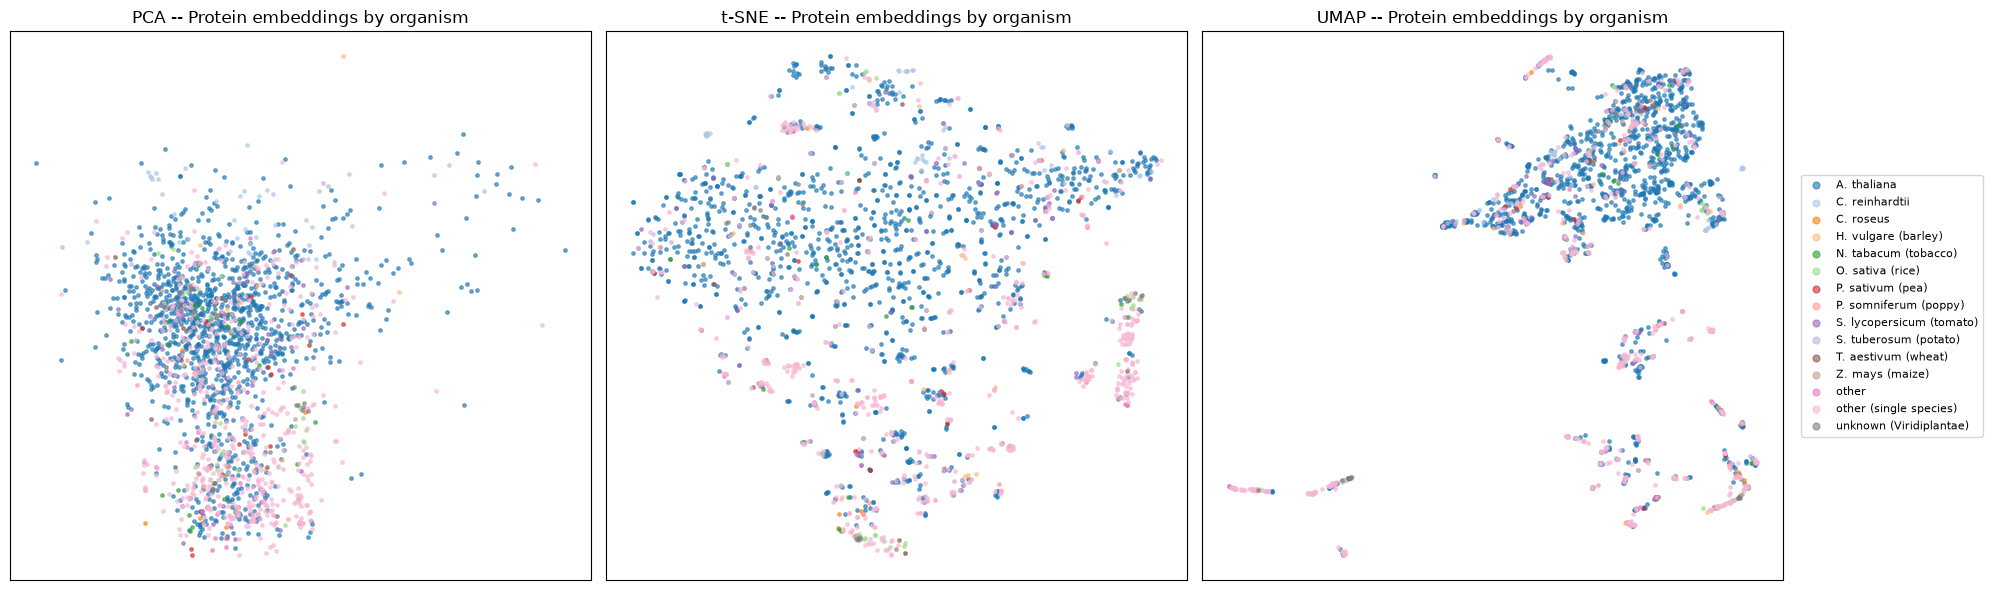


GeneProduct: projecting 1,354/2,741 embedded nodes (1024-dim)


/lustre/BIF/nobackup/delp003/miniforge3/envs/pathway-reaction-kg/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


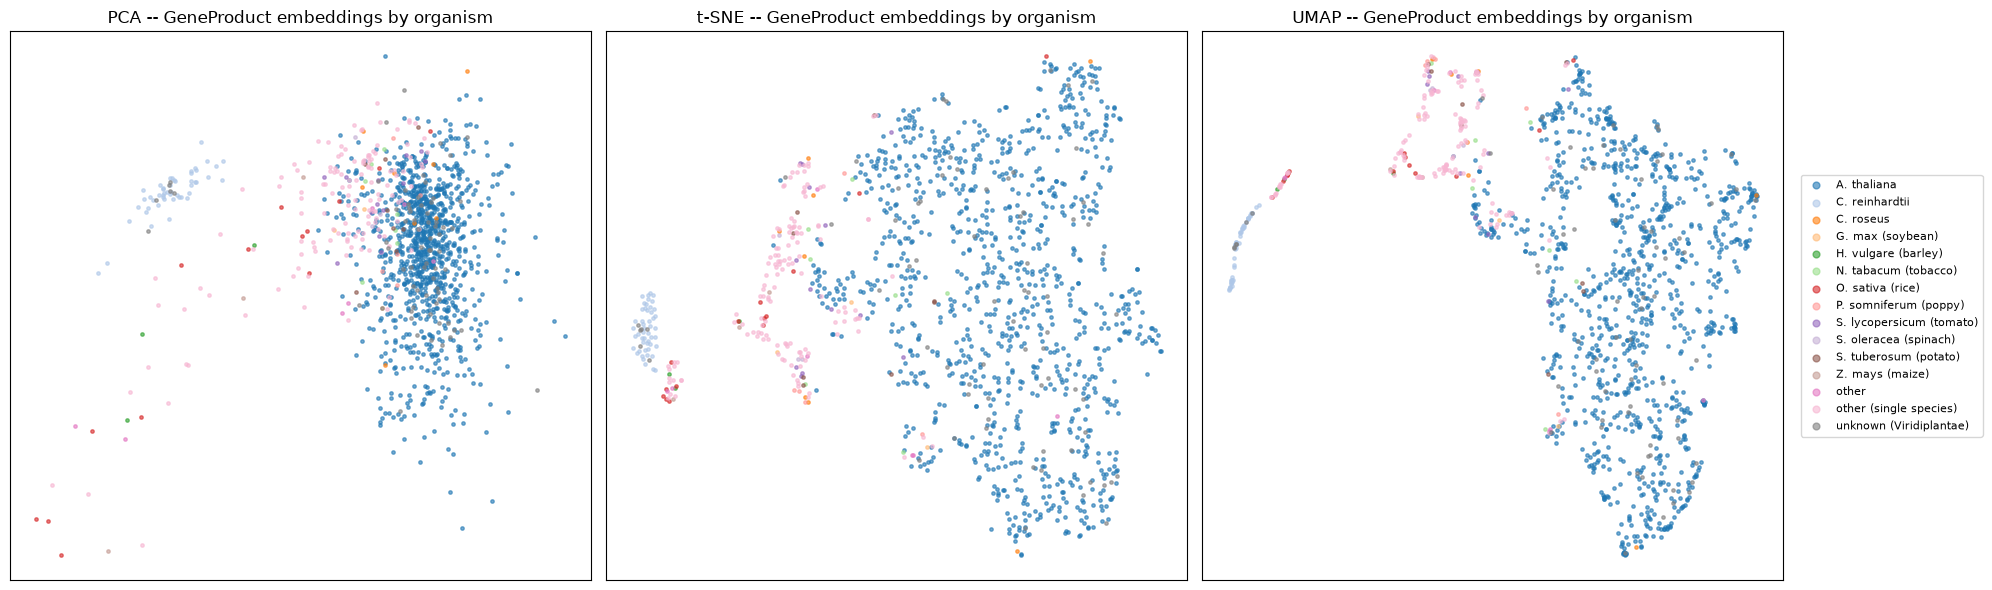


Metabolite: projecting 4,199/4,577 embedded nodes (1024-dim)


/lustre/BIF/nobackup/delp003/miniforge3/envs/pathway-reaction-kg/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


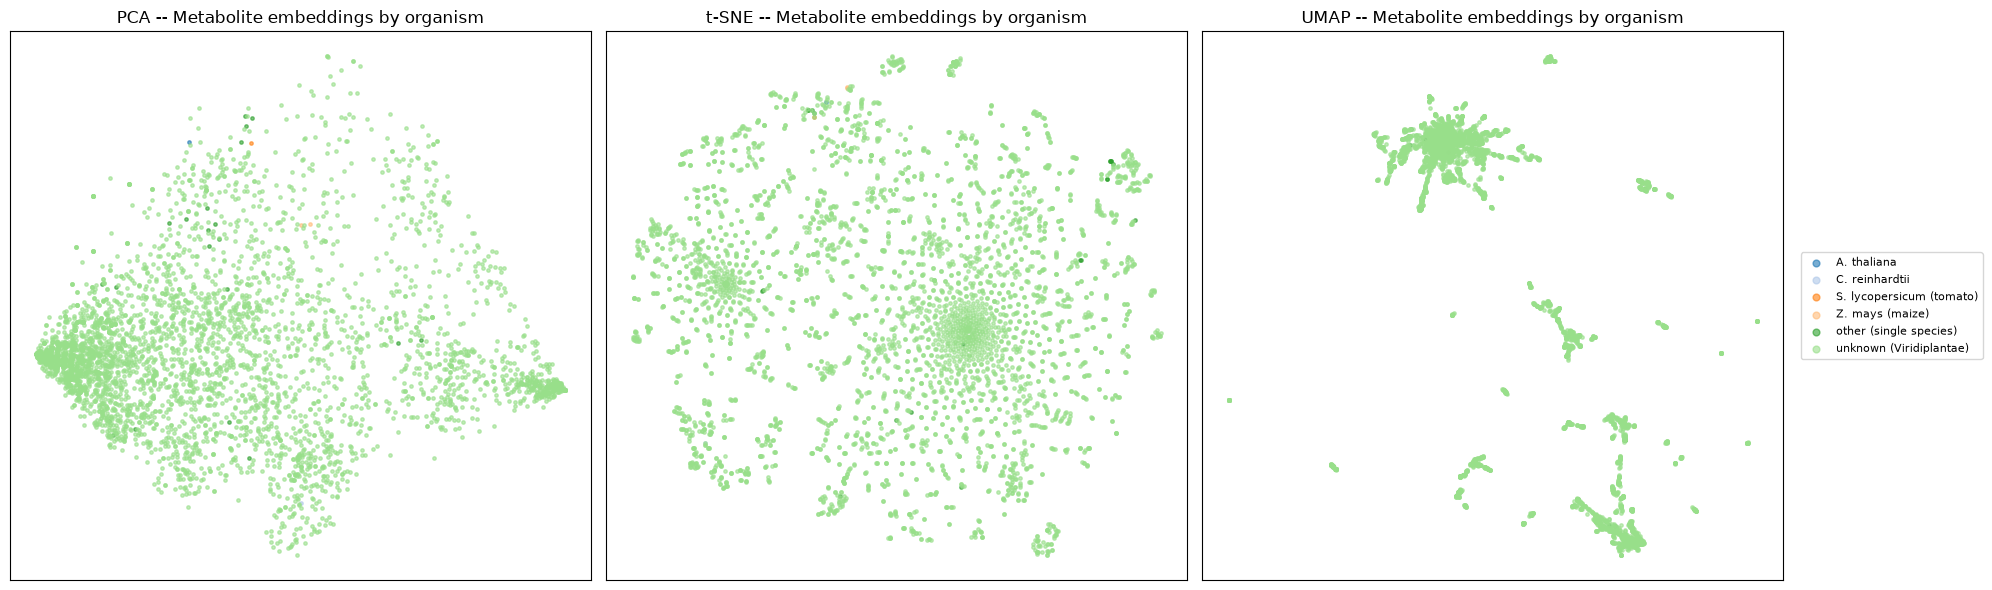

In [4]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

RANDOM_SEED = 42
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def embedded_mask(ntype: str) -> np.ndarray:
    x = data[ntype].x
    return (x.abs().sum(1) > 0).numpy()


def plot_projections(X: np.ndarray, labels: np.ndarray, title: str, save_name: str, max_categories: int = 14):
    """3-panel PCA / t-SNE / UMAP scatter, coloured by `labels`."""
    # Keep the legend readable: the most frequent categories get their own colour,
    # everything past max_categories is folded into "other".
    top_cats = list(pd.Series(labels).value_counts().head(max_categories).index)
    plot_labels = np.where(np.isin(labels, top_cats), labels, "other")
    cats = sorted(set(plot_labels))
    cmap = plt.get_cmap("tab20")
    colors = {c: cmap(i % 20) for i, c in enumerate(cats)}

    pca = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(X)
    tsne = TSNE(n_components=2, random_state=RANDOM_SEED, init="pca", perplexity=30).fit_transform(X)
    umap_emb = UMAP(n_components=2, random_state=RANDOM_SEED).fit_transform(X)

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for ax, proj, name in zip(axes, [pca, tsne, umap_emb], ["PCA", "t-SNE", "UMAP"]):
        for c in cats:
            m = plot_labels == c
            ax.scatter(proj[m, 0], proj[m, 1], s=6, alpha=0.6, label=c, color=colors[c])
        ax.set_title(f"{name} -- {title}")
        ax.set_xticks([]); ax.set_yticks([])
    axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, markerscale=2)
    plt.tight_layout()
    fig.savefig(FIG_DIR / save_name, dpi=150, bbox_inches="tight")
    plt.show()
    return pca, tsne, umap_emb


proj_results = {}
for ntype in ["Protein", "GeneProduct", "Metabolite"]:
    mask = embedded_mask(ntype)
    X = data[ntype].x[mask].numpy()
    labels = node_organism_labels(ntype)[mask]
    print(f"\n{ntype}: projecting {mask.sum():,}/{len(mask):,} embedded nodes ({X.shape[1]}-dim)")
    proj_results[ntype] = plot_projections(
        X, labels, title=f"{ntype} embeddings by organism", save_name=f"embedding_organism_{ntype.lower()}.png"
    )


### 2.3 Interpretation

**Protein (ESM, sequence-based)**: *A. thaliana* dominates by sheer count (it's
the best-annotated reference genome, see `notebooks/03_embeddings_fulldata.ipynb`
§4.3), forming the large central mass in all three projections. UMAP pulls out
a handful of small, visually distinct satellite clusters of non-Arabidopsis
points — plausible, since ESM embeddings primarily encode sequence
homology/function, with species being a real but secondary axis (plant
enzymes performing the same reaction are often conserved across species, so
strong organism clustering isn't expected even with perfect data).

**GeneProduct (PlantCaduceus, DNA-sequence-based)**: shows a *more* visually
separated cluster than Protein does, off to one side in all three projections.
That's consistent with biology, not necessarily an artifact: DNA-level
features (codon usage, GC content, nucleotide composition) carry a stronger
species-specific signal than protein sequence does, since protein sequence is
under much stronger functional/purifying selection across species.

**Metabolite (MAP4, structure-based)**: essentially **no organism signal** —
and that's expected on two counts. First, organism tagging for `Metabolite`
nodes is almost entirely the generic `NCBITaxon_33090` ("Viridiplantae")
fallback (4,551/4,577 embedded metabolites here — far worse even than the
53% system-wide rate noted in `README.md`'s "Known issue" section), so there's
barely any real label to colour by. Second, even with perfect labels this
wouldn't be expected to cluster by species: a metabolite's chemical structure
is identical regardless of which organism's pathway page it's annotated
under (glucose is glucose). The visible UMAP sub-islands are real structure
nonetheless — just driven by chemical class (e.g. lipids vs. sugars vs. amino
acids), not species. Worth checking against `AlternativeId_Chebi`/structural
class annotations in a follow-up if that distinction matters for a write-up.

**Takeaway for splits**: this is exactly why the taxa-held-out split
(§3 below) is the interesting generalisation test for `Protein`/`GeneProduct`
— if held-out organisms' points were totally indistinguishable from training
organisms in embedding space, the model would have an easy time; the partial
separation seen above suggests genuine cross-species generalisation is being
asked of the model, not a trivial recall task.

## Part 3 -- Does the taxa-held-out split carve out a distinct region?

Re-uses the **same** Protein PCA/t-SNE/UMAP coordinates computed in §2.2
(`proj_results["Protein"]`), just recoloured by split membership instead of
organism — so any visual difference between this plot and §2.2's Protein
panel is purely about the colouring, not a different projection.

Only `splits_taxa.pt` is used here: it's the one split where each `Protein`
node maps to **exactly one** split by construction (one organism -> one
split, see `notebooks/02_build_splits.ipynb` §5.0/§5.2). `splits.pt` (random)
and `splits_pathway.pt` assign individual **edges**, not proteins, to splits —
the same protein can appear in train and val/test edges simultaneously, so
"this protein's split" isn't a well-defined single label for those two.

Protein split-label counts (all nodes):
train                          2693
test                            389
val                             374
(not a target-edge protein)     294
Name: count, dtype: int64

Of the 2,067 embedded Protein nodes:
train                          1730
(not a target-edge protein)     165
test                            141
val                              31
Name: count, dtype: int64


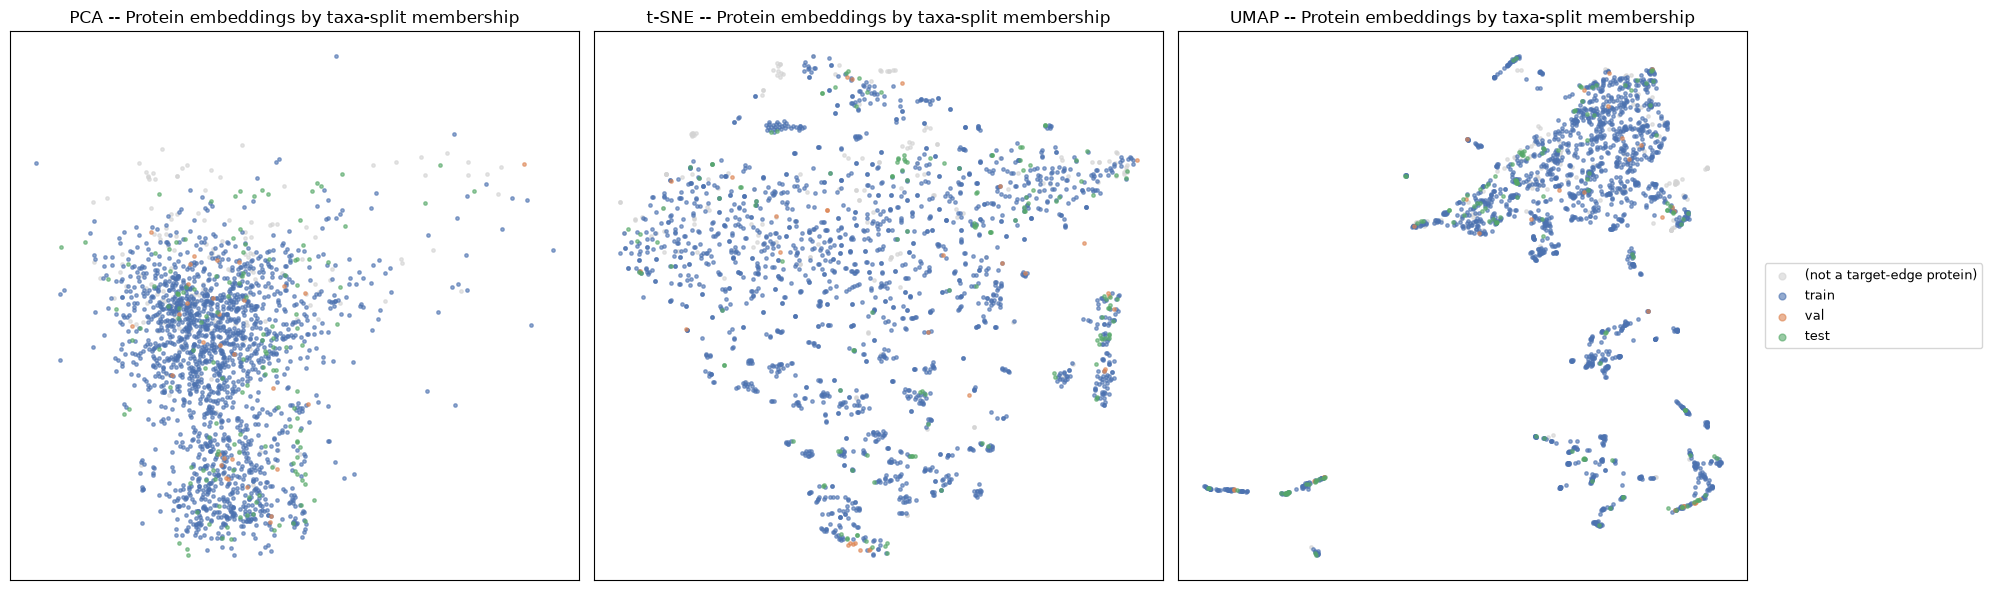

In [5]:
taxa = torch.load(FULL_DIR / "splits_taxa.pt", weights_only=False)

protein_split = np.full(data["Protein"].num_nodes, "(not a target-edge protein)", dtype=object)
for split_name in ["train", "val", "test"]:
    idx = taxa[f"{split_name}_edge_index"][0].unique().numpy()
    conflict = (protein_split[idx] != "(not a target-edge protein)") & (protein_split[idx] != split_name)
    if conflict.any():
        print(f"WARNING: {conflict.sum()} protein(s) already assigned before '{split_name}' -- unexpected overlap")
    protein_split[idx] = split_name

print("Protein split-label counts (all nodes):")
print(pd.Series(protein_split).value_counts())

mask = embedded_mask("Protein")
split_labels_embedded = protein_split[mask]
print(f"\nOf the {mask.sum():,} embedded Protein nodes:")
print(pd.Series(split_labels_embedded).value_counts())

pca, tsne, umap_emb = proj_results["Protein"]
split_colors = {"train": "#4c72b0", "val": "#dd8452", "test": "#55a868",
                "(not a target-edge protein)": "lightgray"}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, proj, name in zip(axes, [pca, tsne, umap_emb], ["PCA", "t-SNE", "UMAP"]):
    for split_name in ["(not a target-edge protein)", "train", "val", "test"]:
        m = split_labels_embedded == split_name
        ax.scatter(proj[m, 0], proj[m, 1], s=6, alpha=0.6, label=split_name, color=split_colors[split_name])
    ax.set_title(f"{name} -- Protein embeddings by taxa-split membership")
    ax.set_xticks([]); ax.set_yticks([])
axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9, markerscale=2)
plt.tight_layout()
fig.savefig(FIG_DIR / "embedding_split_protein.png", dpi=150, bbox_inches="tight")
plt.show()


### 3.1 Interpretation

Of the 2,067 embedded `Protein` nodes, only 31 are `val` and 141 `test`
(taxa split deliberately holds out *whole organisms*, and most organisms are
small — see `notebooks/02_build_splits.ipynb` §5.2's organism list) — so
don't expect a dramatic, sharply-separated blob the way §2.2's organism
colouring shows; there just aren't many held-out points to look at.

What's there is still informative: `val`/`test` points are **not** spread
uniformly through the train-dominated mass — several of them land inside the
same small UMAP satellite clusters that §2.2 identified as non-Arabidopsis
regions, rather than being randomly speckled throughout. That's the expected
picture for a meaningful organism-held-out split: train is dominated by
*A. thaliana* (the big central mass, mostly blue here too), and held-out
organisms' proteins occupy a real, if minority, region of embedding space
that train barely touches — consistent with this split testing genuine
cross-species generalisation rather than near-duplicate recall. If `val`/
`test` points instead sat *exactly* on top of dense train regions, that would
suggest the held-out organisms are too similar to *A. thaliana* to be a
meaningful test.

## Part 4 -- Conversion (reaction) embeddings, coloured by EC class

### 4.1 Load conversion embeddings and EC-class labels

`Conversion` nodes (the `Interaction` subtype that is this project's link-prediction
target) don't have a pre-attached embedding in `heterodata.pt` the way
Protein/Metabolite/GeneProduct do -- they get random 64-dim features by default
(see `dataset.py` / `learnathon/dataset.py`). `scripts/compute_conversion_embeddings.py`
instead builds a **3072-dim substrate-product reaction fingerprint** per Conversion:
`[mean(substrate MAP4), mean(product MAP4), substrate - product]`, saved to
`data/processed/embeddings_conversion.pt`. This is what we project here.

Organism doesn't apply as a colouring dimension the way it does for Protein/
GeneProduct/Metabolite (§2.2): a reaction's chemistry is the same regardless of
which organism's pathway page mentions it -- same reasoning as the Metabolite
case in §2.3. Instead we colour by **EC (Enzyme Commission) top-level class**,
parsed from `data/interim/reactions.ttl` with the same
`parse_ec_from_reactions_ttl()` helper used in
`training/fulldata_baseline_common.py::attach_ec_features()` -- this is the
natural "type" label for a reaction, analogous to what organism is for a protein.</cell_type>


In [6]:
import sys

sys.path.insert(0, str(ROOT / "training"))
from fulldata_baseline_common import parse_ec_from_reactions_ttl

EC_TTL_PATH = ROOT / "data" / "interim" / "reactions.ttl"
EC_NAMES = {
    "1": "Oxidoreductases", "2": "Transferases", "3": "Hydrolases",
    "4": "Lyases", "5": "Isomerases", "6": "Ligases", "7": "Translocases",
}

ec_by_local = parse_ec_from_reactions_ttl(EC_TTL_PATH)

conv_nodes = nodes[nodes["interaction_subtype"] == "Conversion"].reset_index(drop=True)
conv_ids = conv_nodes["node_id"].tolist()

conv_emb: dict[str, torch.Tensor] = torch.load(FULL_DIR / "embeddings_conversion.pt", weights_only=False)
print(f"Conversion nodes: {len(conv_ids):,}  |  fingerprints in embeddings_conversion.pt: {len(conv_emb):,}")


def conv_ec_labels(ids: list[str]) -> np.ndarray:
    """Top-level EC class name per Conversion node id, '(no EC annotation)' if none."""
    labels = []
    for nid in ids:
        local = nid.rsplit("/", 1)[-1]
        ec_str = ec_by_local.get(local)
        labels.append(EC_NAMES.get(ec_str.split(".")[0], "(no EC annotation)") if ec_str else "(no EC annotation)")
    return np.array(labels)


ec_labels_all = conv_ec_labels(conv_ids)
print("\nEC class breakdown (all Conversion nodes):")
print(pd.Series(ec_labels_all).value_counts())


  Loading reactions.ttl with rdflib (one-off, ~30-60 s)...


  Parsed 3,826,567 triples


Conversion nodes: 19,927  |  fingerprints in embeddings_conversion.pt: 19,927

EC class breakdown (all Conversion nodes):
(no EC annotation)    6342
Oxidoreductases       5418
Transferases          4893
Hydrolases            1303
Lyases                1064
Ligases                657
Isomerases             193
Translocases            57
Name: count, dtype: int64


### 4.2 PCA / t-SNE / UMAP, coloured by EC class

Same `plot_projections()` helper as §2.2. As with the other node types, only
Conversions with a **non-zero** fingerprint are projected -- `compute_conversion_embeddings.py`
falls back to an all-zero 3072-dim vector when neither substrate nor product
metabolites resolved to a MAP4 embedding, which would otherwise pile up as a
fake cluster at the origin.

Conversion: projecting 13,717/19,927 nodes with a non-zero fingerprint (3072-dim)


/lustre/BIF/nobackup/delp003/miniforge3/envs/pathway-reaction-kg/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/lustre/BIF/nobackup/delp003/miniforge3/envs/pathway-reaction-kg/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


/lustre/BIF/nobackup/delp003/miniforge3/envs/pathway-reaction-kg/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/lustre/BIF/nobackup/delp003/miniforge3/envs/pathway-reaction-kg/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/lustre/BIF/nobackup/delp003/miniforge3/envs/pathway-reaction-kg/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!


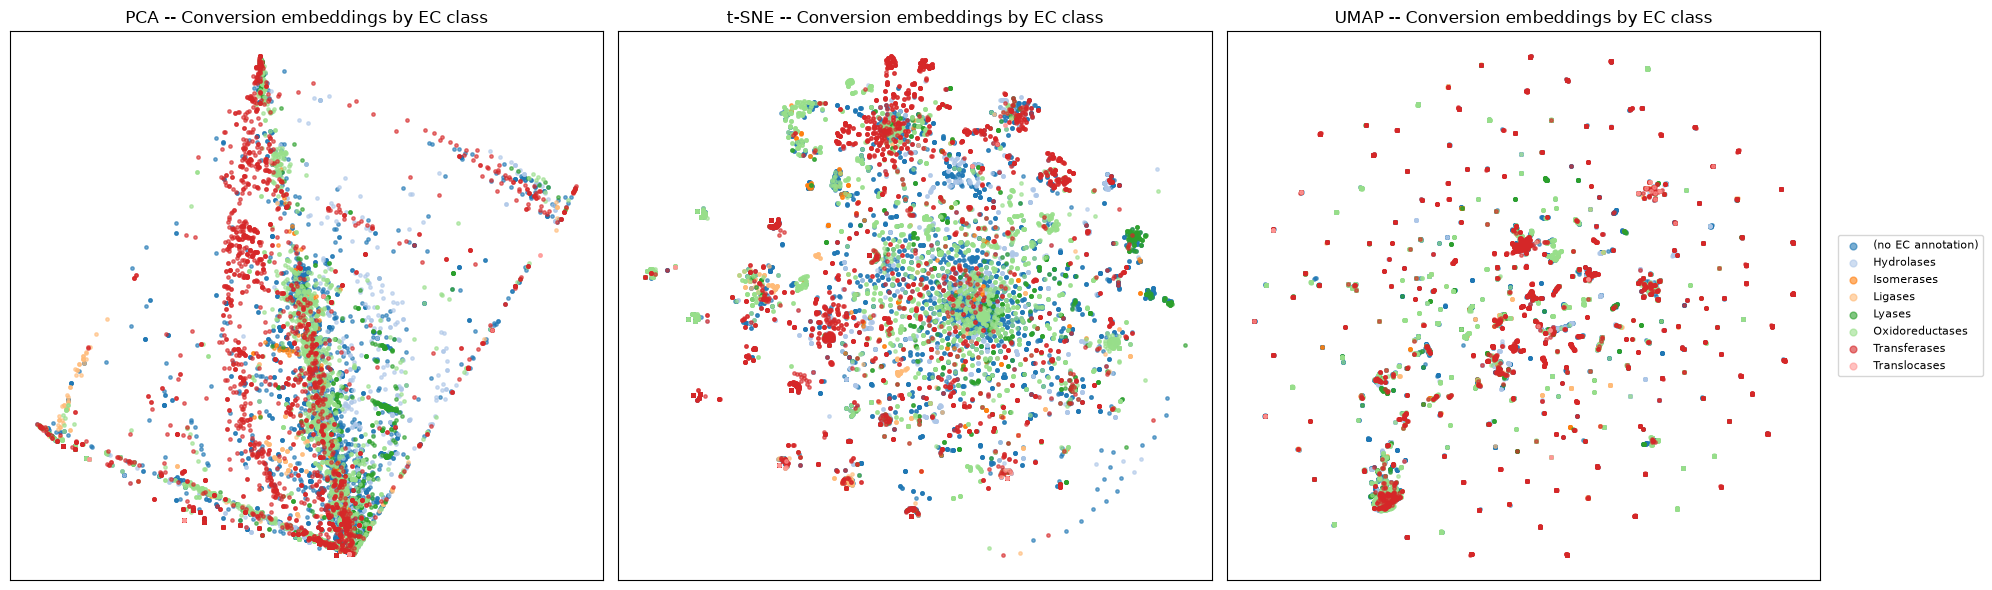

In [7]:
conv_emb_matrix = torch.stack([conv_emb.get(nid, torch.zeros(3072)) for nid in conv_ids])
conv_mask = (conv_emb_matrix.abs().sum(1) > 0).numpy()

X = conv_emb_matrix[conv_mask].numpy()
labels = ec_labels_all[conv_mask]
print(f"Conversion: projecting {conv_mask.sum():,}/{len(conv_mask):,} nodes with a non-zero fingerprint ({X.shape[1]}-dim)")

proj_results["Conversion"] = plot_projections(
    X, labels, title="Conversion embeddings by EC class", save_name="embedding_ecclass_conversion.png"
)


### 4.3 Interpretation

**No clean global separation by EC class**, in any of the three projections —
unlike GeneProduct's organism clustering in §2.2, there's no single region
that's predominantly one enzyme class. This is expected: a substrate-product
MAP4 fingerprint encodes the **chemical identity of the specific metabolites**
in a reaction, not the catalytic mechanism (bond formed/broken) that defines
an EC class. Two Transferase reactions with completely different substrates
can sit far apart, while a Transferase and an Oxidoreductase that happen to
share a common cofactor (ATP, NAD+) can land close together.

**t-SNE and UMAP do carve out a number of small, visually tight, near-monochromatic
islands** (e.g. the dark-green Oxidoreductase cluster at the right edge of the
t-SNE panel, several small red Transferase satellites). These are more plausibly
near-duplicate reactions built from the same core substrate/product pair (e.g.
the same cofactor chemistry recurring across many pathway variants) than
genuine EC-class structure — consistent with the "large hairball + small tight
satellites" shape also seen for Protein in §2.2, but here the satellites don't
line up with the colouring the way organism did for Protein.

**Oxidoreductases (green) and Transferases (red) dominate by count** (5,418
and 4,893 of the 13,585 EC-annotated Conversions here — matching the "plant
metabolism dominated by Transferases/Oxidoreductases" note in
`notebooks/04_link_prediction.ipynb` §2.3) and are also the two colours that
streak furthest along the PCA "fan" edges. That's consistent with these being
both the most common *and* the most chemically diverse classes in plant
metabolism — they show up everywhere rather than in one place, rather than
forming a class-specific region.

**"(no EC annotation)" (blue) is scattered throughout, not isolated** — 6,342
of the 19,927 Conversion nodes have no `EC-` xrefId in `reactions.ttl`, but
they aren't chemically distinct from annotated reactions; this is consistent
with missing EC annotation being a gap in the source RDF rather than a marker
of some different reaction type.

**Takeaway**: since substrate/product structure (this fingerprint) and EC
class are only loosely coupled, they carry complementary information — which
is exactly why `attach_ec_features()` in `training/fulldata_baseline_common.py`
**concatenates** an EC one-hot onto the Conversion features on top of (not
instead of) this MAP4 fingerprint (see commit `efb7c90`): the GNN gets both
"what molecules are involved" and an explicit "what type of chemistry"
signal, rather than having to infer the latter from the former.